In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
state_users = pd.read_excel("phonepe.xlsx", sheet_name="State_Txn and Users")
state_split = pd.read_excel("phonepe.xlsx", sheet_name="State_TxnSplit")
state_device = pd.read_excel("phonepe.xlsx", sheet_name="State_DeviceData")
district_users = pd.read_excel("phonepe.xlsx", sheet_name="District_Txn and Users")
district = pd.read_excel("phonepe.xlsx", sheet_name="District Demographics")

## 📚 Menu <a id="Menu"></a>

---

## 🗂 File Explorations

#### 🏛 State Level
- 🔎 [State Transactions & Users — File + Data Exploration](#StateUsersFE)  
  ↳ 📌 [Observations](#StateUsersFEO) 

- 🔎 [State Transactions (Split) — File + Data Exploration](#StateSplitFE)  
  ↳ 📌 [Observations](#StateSplitFEO) 

- 🔎 [State Device Data — File + Data Exploration](#StateDeviceFE)  
  ↳ 📌 [Observations](#StateDeviceFEO) 

---

#### 🏙 District Level
- 🔎 [District Transactions & Users — File + Data Exploration](#DistrictUsersFE)  
  ↳ 📌 [Observations](#DistrictUsersFEO) _(Active)_ 

- 🔎 [District Demographics — File + Data Exploration](#DistrictFE)  
  ↳ 📌 [Observations](#DistrictFEO)


---

## 🧪 Tests
#### 🖊️[App Penetration Testing - State](#PenState)
- Rationale for Analysis
- Key Observations (State Strategic Growth – 2021 Q2)
- Top 5 Business Move Suggestions (State-Level Strategy)

---
### ✔︎ Conclusion
- [Semi-Conclusion in Absence of Strategic Input](#Conc)

### <a id='StateUsersFE'>1. State Transactions and Users File and Data Exploration</a>

In [101]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)
state_users

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,14631761,2198,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,28338536,2499,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,55557471,3416,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,90548336,3811,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,102299741,3356,18596,0
...,...,...,...,...,...,...,...,...
499,West Bengal,2020,2,57676797,100099431877,1736,13222022,198589332
500,West Bengal,2020,3,79954504,156813355855,1961,14448366,246554831
501,West Bengal,2020,4,100340645,199165491366,1985,15662093,291721919
502,West Bengal,2021,1,118254052,242937207476,2054,16808799,316832674


In [95]:
state_users.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,504,2019,1,2018,2018,2019,2020,2021
Quarter,504,2,1,1,1,2,3,4
Transactions,504,40740001,82287143,778,592558,6217487,43636746,573616486
Amount (INR),503,70833320602,144090233156,1928611,1167157029,10516054014,69470450912,1027958332798
ATV (INR),504,1993,607,0,1599,1861,2259,3939
Registered Users,504,4777501,6644496,501,157420,1747914,7320945,39664697
App Opens,504,97744705,204237580,0,0,2930574,86150218,1208083592


In [5]:
state_users.dtypes

State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

## <a id="StateUsersFEO">Observations</a>

[⬅ Go Back to Menu](#Menu)

---

### 🫙 Missing Values
- Total **Missing Value** in Dataset - 1 value is missing in Amount

---

### Workforce Planning
- Transaction value is heavily concentrated in a few large states, requiring disproportionate workforce allocation there.
- Many smaller states contribute marginally, suggesting a lean, hub-based staffing model rather than full local deployment.

---

### Strategic Growth
- The long tail of underpenetrated states presents expansion headroom, especially if localized growth strategies are executed effectively.

---

### Monetization & Market Segmentation Strategy
- **High-ATV states (e.g., Ladakh, Andaman)** → Target premium and high-ticket financial products.
- **Large but lower-ATV states (e.g., Maharashtra, Karnataka)** → Focus on increasing ticket size via upsell and cross-sell.
- **Mid-ATV states (near national average)** → Use as stable markets for piloting growth initiatives.

In [6]:
state_users[state_users.isna().any(axis=1)]

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,NaN,0,18363733,957709447


In [7]:
state_users.loc[:,state_users.isna().any(axis=0)]

,Amount (INR)
0,14631761
1,28338536
2,55557471
3,90548336
4,102299741
...,...
499,100099431877
500,156813355855
501,199165491366
502,242937207476


In [8]:
state_users.isna().sum()

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64

In [9]:
state_users[state_users["Amount (INR)"].isna()]

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,NaN,0,18363733,957709447


In [98]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
cumulative = state_users.groupby("State")["Amount (INR)"].sum().reset_index().sort_values("Amount (INR)", ascending=False)
total = cumulative["Amount (INR)"].sum()
cumulative["Percent% Share"] = cumulative["Amount (INR)"]/total*100
cumulative

,State,Amount (INR),Percent% Share
31,Telangana,4574245879737.88,12.84
15,Karnataka,4361395878908.12,12.24
20,Maharashtra,4290995253332.02,12.04
1,Andhra Pradesh,3187847468851.51,8.95
28,Rajasthan,2625584351280.98,7.37
33,Uttar Pradesh,2399757104087.38,6.74
19,Madhya Pradesh,1915100967832.55,5.38
8,Delhi,1649942211116.08,4.63
4,Bihar,1639578926751.51,4.60
30,Tamil Nadu,1481448044165.06,4.16


In [100]:
cumulative = state_users.groupby("State")["ATV (INR)"].mean().reset_index().sort_values("ATV (INR)", ascending=False)
mean_ = cumulative["ATV (INR)"].mean()
cumulative["Deviation"] = cumulative["ATV (INR)"]/mean_*100
cumulative

,State,ATV (INR),Deviation
17,Ladakh,3408.22,170.97
0,Andaman & Nicobar Islands,3159.27,158.48
23,Mizoram,2927.52,146.86
18,Lakshadweep,2776.12,139.26
2,Arunachal Pradesh,2638.32,132.35
21,Manipur,2621.23,131.49
24,Nagaland,2609.94,130.92
13,Jammu & Kashmir,2508.51,125.84
5,Chandigarh,2113.80,106.04
29,Sikkim,2087.84,104.73


### <a id='StateSplitFE'>2. State Transactions Split File and Data Exploration</a>

[⬅ Go Back to Menu](#Menu)

In [10]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)
state_split.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,202240249483,3754
2505,West Bengal,2021,1,Merchant payments,37143701,28918343691,779
2506,West Bengal,2021,1,Recharge & bill payments,26673733,11339665945,425
2507,West Bengal,2021,1,Financial Services,166727,175445812,1052
2508,West Bengal,2021,1,Others,400816,263502545,657
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,230812278789,3570
2510,West Bengal,2021,2,Merchant payments,41696787,34787867208,834
2511,West Bengal,2021,2,Recharge & bill payments,34799709,13331453858,383
2512,West Bengal,2021,2,Financial Services,190537,186466488,979
2513,West Bengal,2021,2,Others,549353,316744716,577


## <a id="StateSplitFEO">Observations</a>

[⬅ Go Back to Menu](#Menu)

---

### 🫙 Missing Values
- No **Missing Value** in Dataset

---

### 📊 Charting
- Peer-to-peer is dominating both volume and value.
- Merchant Payments have High Volume, but Low Ticket Size.
- Recharge & Bill Payments = Frequency, Not Value

In [11]:
state_split.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2514,2019,1,2018,2018,2019,2020,2021
Quarter,2514,2,1,1,1,2,3,4
Transactions,2514,8167446,24236454,2,27881,268798,3683230,279599017
Amount (INR),2514,14439779210,59950544781,34,17624122,190118949,2661247757,872151973638
ATV (INR),2514,1350,1535,17,386,721,1353,7768


In [12]:
t_type_consolidated = (
    state_split.groupby("Transaction Type").agg({
        "Transactions": "sum",
        "Amount (INR)": "sum",
        "ATV (INR)": "mean"
    }).reset_index()
)
t_type_consolidated

,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,Financial Services,47996333,21753937260,723
1,Merchant payments,6959228853,3864436500281,817
2,Others,117964108,68908592581,810
3,Peer-to-peer payments,9161937793,30581698814753,4049
4,Recharge & bill payments,4245833207,1764807087901,343


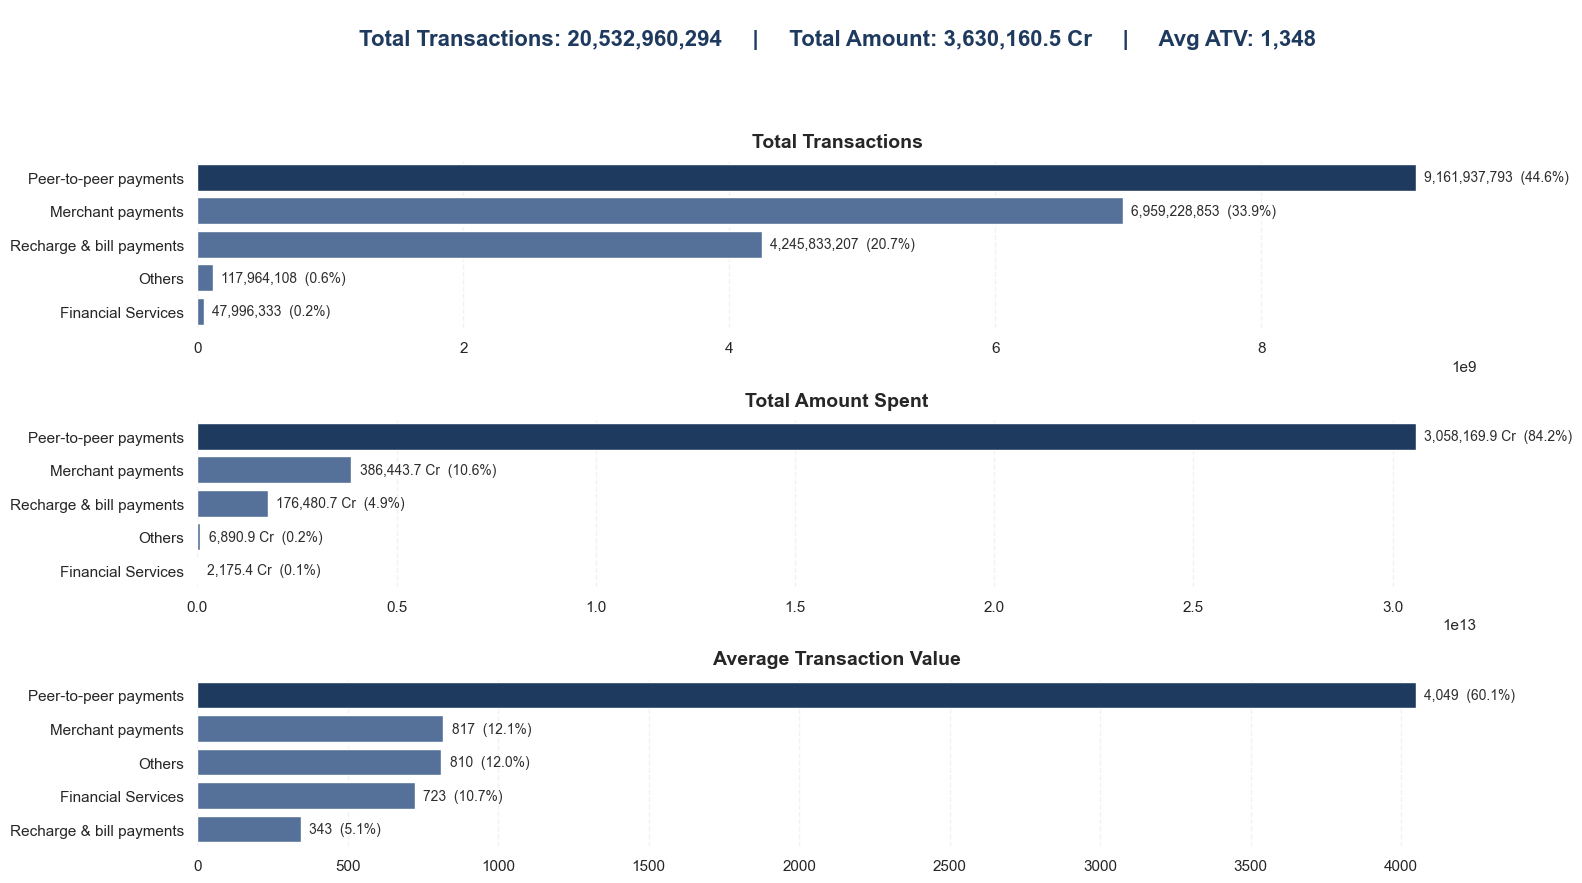

In [13]:
sns.set_theme(style="white")

# ---------- Helpers ----------

def format_inr(value):
    if value >= 1e7:
        return f"{value/1e7:,.1f} Cr"
    elif value >= 1e5:
        return f"{value/1e5:,.1f} L"
    else:
        return f"{value:,.0f}"

def add_labels(ax, total, is_currency=False):
    for p in ax.patches:
        width = p.get_width()
        pct = width / total * 100
        
        if is_currency:
            value_text = format_inr(width)
        else:
            value_text = f"{width:,.0f}"
        
        label = f"{value_text}  ({pct:.1f}%)"
        
        ax.annotate(
            label,
            (width, p.get_y() + p.get_height()/2),
            ha='left',
            va='center',
            fontsize=10,
            color="#2E2E2E",
            xytext=(6, 0),
            textcoords='offset points'
        )

# ---------- Figure Layout (PPT Friendly 16:9) ----------

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(4, 1, height_ratios=[0.9, 2.5, 2.5, 2.5])

# ---------- KPI Summary Row ----------

kpi_ax = fig.add_subplot(gs[0])
kpi_ax.axis("off")

total_txn = t_type_consolidated["Transactions"].sum()
total_amt = t_type_consolidated["Amount (INR)"].sum()
avg_atv = t_type_consolidated["ATV (INR)"].mean()

kpi_text = (
    f"Total Transactions: {total_txn:,.0f}     |     "
    f"Total Amount: {format_inr(total_amt)}     |     "
    f"Avg ATV: {format_inr(avg_atv)}"
)

kpi_ax.text(
    0.5, 0.5,
    kpi_text,
    ha='center',
    va='center',
    fontsize=16,
    weight='bold',
    color="#1F3A5F"
)

# ---------- Corporate Colors ----------

CORP_BLUE = "#1F3A5F"
LIGHT_BLUE = "#4A6FA5"

plots = [
    ("Transactions", "Total Transactions", False),
    ("Amount (INR)", "Total Amount Spent", True),
    ("ATV (INR)", "Average Transaction Value", True)
]

# ---------- Bar Charts ----------

for i, (col, title, is_currency) in enumerate(plots, start=1):
    
    ax = fig.add_subplot(gs[i])
    
    df = t_type_consolidated.sort_values(col, ascending=False)
    total = df[col].sum()
    
    sns.barplot(
        ax=ax,
        data=df,
        y="Transaction Type",
        x=col,
        color=LIGHT_BLUE
    )
    
    # Highlight top performer
    ax.patches[0].set_facecolor(CORP_BLUE)
    
    ax.set_title(title, fontsize=14, weight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.grid(axis='x', linestyle='--', alpha=0.25)
    sns.despine(left=True, bottom=True)
    
    add_labels(ax, total, is_currency=is_currency)

plt.tight_layout()
plt.show()

In [14]:
state_split.dtypes

State                object
Year                  int64
Quarter               int64
Transaction Type     object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

In [15]:
state_split.isna().sum()

State               0
Year                0
Quarter             0
Transaction Type    0
Transactions        0
Amount (INR)        0
ATV (INR)           0
dtype: int64

### <a id='StateDeviceFE'>3. State Device Data File and Data Exploration</a>

[⬅ Go Back to Menu](#Menu)

In [67]:
state_device.iloc[195:200]

,State,Year,Quarter,Brand,Registered Users,Percentage
195,Andhra Pradesh,2018,4,Huawei,176237,0.03
196,Andhra Pradesh,2018,4,Lenovo,149583,0.02
197,Andhra Pradesh,2018,4,Others,556203,0.08
198,Andhra Pradesh,2019,1,Xiaomi,2110547,0.25
199,Andhra Pradesh,2019,1,Samsung,1688342,0.20


In [16]:
state_device.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,5544,2019,1,2018,2018,2019,2020,2021
Quarter,5544,2,1,1,1,2,3,4
Registered Users,5544,434318,905607,10,8056,74422,397888,9764252
Percentage,5544,0,0,0,0,0,0,0


In [51]:
5544/(11*14)

36.0

In [64]:
print("\n")
states = state_device["State"].unique()
for state in states[0:4]:
    stat = state_device[(state_device["State"]==state)&(state_device["Year"]==2018) & (state_device["Quarter"]==1)].Percentage.sum()
    print(f"{state} sum of percentage for Q1 of 2018 is {stat}")
print("\n")
states = state_device["State"].unique()
for state in states[0:4]:
    stat = state_device[(state_device["State"]==state)&(state_device["Year"]==2019) & (state_device["Quarter"]==1)].Percentage.sum()
    print(f"{state} sum of percentage for Q1 of 2019 is {stat}")
print("\n")



Andaman & Nicobar Islands sum of percentage for Q1 of 2018 is 0.9999999999999969
Andhra Pradesh sum of percentage for Q1 of 2018 is 0.999999999999998
Arunachal Pradesh sum of percentage for Q1 of 2018 is 0.9999999999999988
Assam sum of percentage for Q1 of 2018 is 0.9999999999999977


Andaman & Nicobar Islands sum of percentage for Q1 of 2019 is 0.999999999999998
Andhra Pradesh sum of percentage for Q1 of 2019 is 0.9999999999999971
Arunachal Pradesh sum of percentage for Q1 of 2019 is 0.9999999999999981
Assam sum of percentage for Q1 of 2019 is 0.9999999999999964




In [65]:
836581/state_device[(state_device["State"]=='Andhra Pradesh')&(state_device["Year"]==2018) & (state_device["Quarter"]==1)]["Registered Users"].sum()

np.float64(0.25073985823255257)

In [56]:
state_device["State"].unique()

array(['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh',
       'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh',
       'Dadra & Nagar Haveli and Daman & Diu', 'Delhi', 'Goa', 'Gujarat',
       'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand',
       'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh',
       'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
       'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttarakhand',
       'Uttar Pradesh', 'West Bengal'], dtype=object)

In [53]:
state_device["State"].value_counts()

State
Andaman & Nicobar Islands               154
Andhra Pradesh                          154
Maharashtra                             154
Manipur                                 154
Meghalaya                               154
Mizoram                                 154
Nagaland                                154
Odisha                                  154
Puducherry                              154
Punjab                                  154
Rajasthan                               154
Sikkim                                  154
Tamil Nadu                              154
Telangana                               154
Tripura                                 154
Uttarakhand                             154
Uttar Pradesh                           154
Madhya Pradesh                          154
Lakshadweep                             154
Ladakh                                  154
Delhi                                   154
Arunachal Pradesh                       154
Assam                     

## <a id="StateDeviceFEO">Observations</a>

[⬅ Go Back to Menu](#Menu)

---

### 🎛️ Table Facts
- There are **20 brands** including 1 for Other Brands
- There are **14 quarters** -- 2018 Q1 to 2021 Q2
- All **36 States and Union Territories** are included

---

### 🫙 Missing Values
- No **Missing Value** in Dataset

---

### 📊 Charting
For the period **2018** to **Q2 of 2021**
- **Xiaomi** consistently has the highest number of registered users
- All Top Five Brands by registered users **shows Continuous Growth**
- The 5 brands -  Xiaomi, Samsung, Vivo, Oppo, Realme


Analysis of the Brand `🍎 Apple`
- Top 3 states (Maharashtra, Karnataka, Telangana) contribute a disproportionately large share of Apple users.
- There is a clear long tail, with many states contributing less than 1% each.

In [85]:
state_device.dtypes

State                object
Year                  int64
Quarter               int64
Brand                object
Registered Users      int64
Percentage          float64
dtype: object

In [75]:
state_device["Brand"].nunique()

20

In [77]:
36*14

504

In [76]:
state_device["Brand"].value_counts()

Brand
Xiaomi        504
Realme        504
Samsung       504
Others        504
Oppo          504
Vivo          504
Motorola      479
Apple         448
Huawei        415
Lenovo        411
OnePlus       375
Micromax      140
Gionee        111
Asus           77
Tecno          21
Lava           17
HMD Global     15
Infinix         8
Lyf             2
COOLPAD         1
Name: count, dtype: int64

In [83]:
brand_device=( state_device.groupby(["Brand", "Year", "Quarter"])["Registered Users"]
                .sum().reset_index()
                .sort_values(["Brand", "Year", "Quarter"])
             )
brand_top_5 = (
    brand_device.groupby("Brand")["Registered Users"].sum().reset_index().nlargest(6,"Registered Users")
)
brand_top_5

,Brand,Registered Users
19,Xiaomi,615566524
16,Samsung,480799591
18,Vivo,411369522
13,Oppo,283522909
14,Others,211221642
15,Realme,134416015


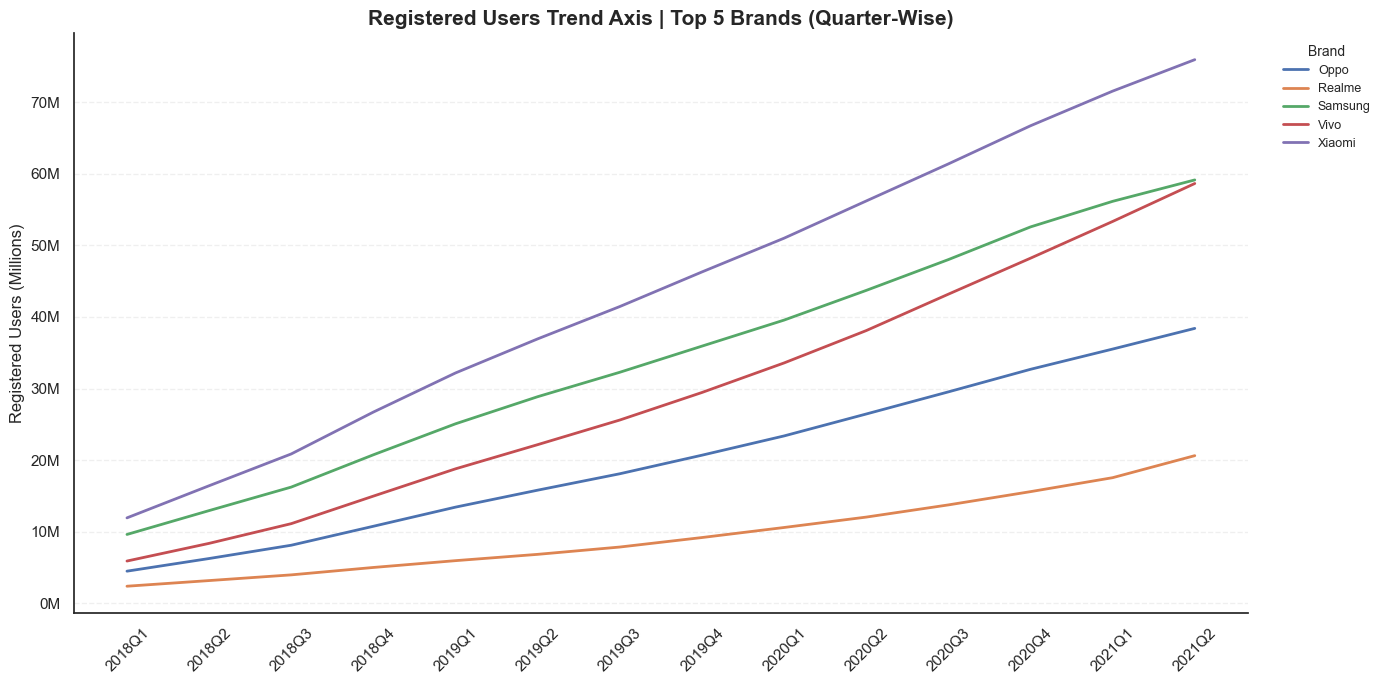

In [84]:

import matplotlib.ticker as mticker

sns.set_theme(style="white")

df = brand_device.copy()
df = df[df["Brand"].isin(['Xiaomi','Samsung', 'Vivo', 'Oppo', 'Realme'])]
df["YearQuarter"] = df["Year"].astype('str')+'Q'+df["Quarter"].astype('str')

plt.figure(figsize=(14,7))

ax = sns.lineplot(
    data = df,
    x = "YearQuarter",
    y = "Registered Users",
    hue = "Brand",
    linewidth = 2
)

# ---- Format Y-axis in Millions ----
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

plt.xticks(rotation=45)
plt.title("Registered Users Trend Axis | Top 5 Brands (Quarter-Wise)", fontsize=15, weight='bold')
plt.xlabel("")
plt.ylabel('Registered Users (Millions)')

ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.legend(
    title="Brand",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()


In [88]:
apple = state_device[(state_device["Brand"]=='Apple') & (state_device["Year"]==2021) & (state_device["Quarter"]==2)].copy()

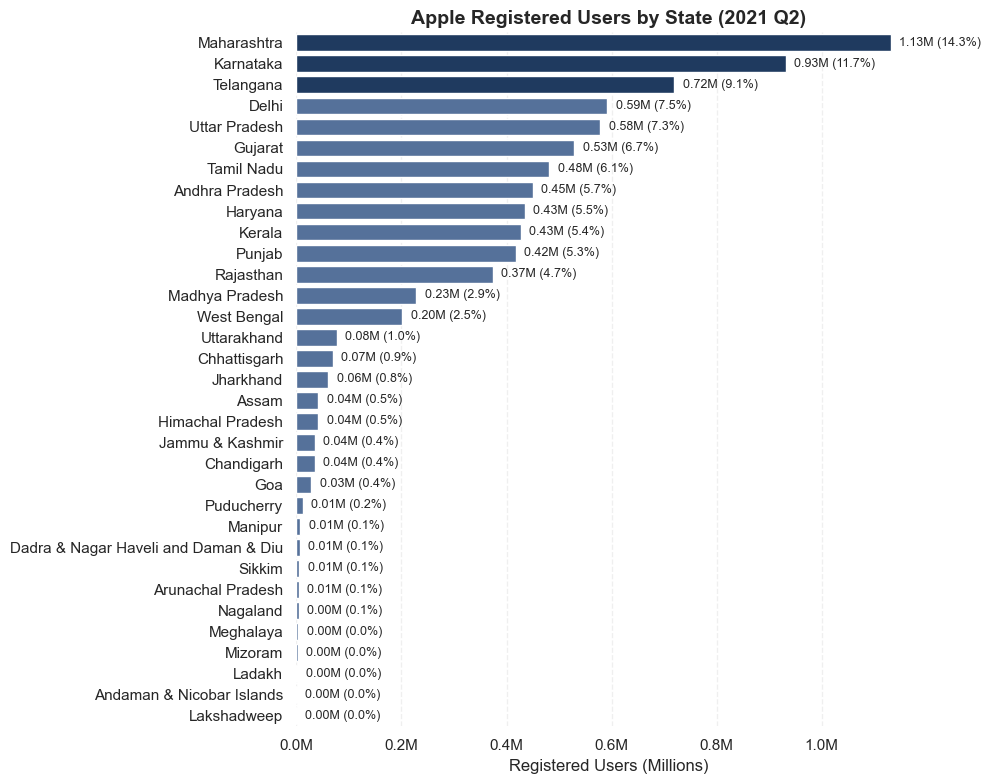

In [93]:
import matplotlib.ticker as mticker

sns.set_theme(style="white")

# Sort ascending for horizontal layout
df_plot = apple.sort_values("Registered Users", ascending=False)

total_users = df_plot["Registered Users"].sum()

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=df_plot,
    y="State",
    x="Registered Users",
    color="#4A6FA5"
)

# ---- Highlight Top 3 ----
for i in range(0, 3):
    ax.patches[i].set_facecolor("#1F3A5F")

# ---- Format X axis in Millions ----
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

# ---- Add Labels with % Share ----
for p in ax.patches:
    width = p.get_width()
    pct = width / total_users * 100
    
    ax.annotate(
        f"{width/1e6:.2f}M ({pct:.1f}%)",
        (width, p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=9,
        xytext=(6, 0),
        textcoords='offset points'
    )

plt.title("Apple Registered Users by State (2021 Q2)", fontsize=14, weight="bold")
plt.xlabel("Registered Users (Millions)")
plt.ylabel("")

ax.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [18]:
state_device.isna().sum()

State               0
Year                0
Quarter             0
Brand               0
Registered Users    0
Percentage          0
dtype: int64

### <a id='DistrictUsersFE'>4. District Transactions and Users File and Data Exploration</a>

[⬅ Go Back to Menu](#Menu)

In [19]:
temp = pd.concat([district_users.iloc[40:50],district_users.tail(10)])
temp

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
40,Andaman & Nicobar Islands,2021,2,North And Middle Andaman,AN02,39200,90233389,2302,8493,596182
41,Andaman & Nicobar Islands,2021,2,South Andaman,AN03,286907,760893021,2652,51903,1270226
42,Andhra Pradesh,2018,1,Anantapur,AP01,638664,788830646,1235,241192,0
43,Andhra Pradesh,2018,1,Chittoor,AP02,830324,1009621878,1216,309541,0
44,Andhra Pradesh,2018,1,East Godavari,AP03,943935,1235785516,1309,350356,0
45,Andhra Pradesh,2018,1,Guntur,AP04,815932,1108686589,1359,317065,0
46,Andhra Pradesh,2018,1,Krishna,AP05,863935,1284255180,1487,323673,0
47,Andhra Pradesh,2018,1,Kurnool,AP06,679623,764905299,1125,240133,0
48,Andhra Pradesh,2018,1,Prakasam,AP07,534757,748990776,1401,189949,0
49,Andhra Pradesh,2018,1,Spsr Nellore,AP08,531612,676643238,1273,194475,0


In [20]:
district_users[district_users["Year"]==2018]["App Opens"].value_counts()

App Opens
0    2928
Name: count, dtype: int64

In [21]:
n_u = {}
for yr in [2018,2019,2020,2021]:
    n_u[yr] = district_users[district_users["Year"]==yr]["App Opens"].nunique()

n_u

{2018: 1, 2019: 2196, 2020: 2927, 2021: 1464}

In [22]:
n_u = district_users.groupby("Year")["App Opens"].nunique()
n_u

Year
2018       1
2019    2196
2020    2927
2021    1464
Name: App Opens, dtype: int64

In [23]:
district_users["Year"].value_counts()

Year
2018    2928
2019    2928
2020    2928
2021    1464
Name: count, dtype: int64

In [24]:
district_users[["Year", "Quarter"]].value_counts()

Year  Quarter
2018  1          732
      2          732
      3          732
      4          732
2019  1          732
      2          732
      3          732
      4          732
2020  1          732
      2          732
      3          732
      4          732
2021  1          732
      2          732
Name: count, dtype: int64

In [25]:
district_users["State"].value_counts()

State
Uttar Pradesh                           1050
Madhya Pradesh                           728
Bihar                                    532
Tamil Nadu                               518
Maharashtra                              504
Assam                                    462
Rajasthan                                462
Gujarat                                  462
Telangana                                462
Karnataka                                420
Odisha                                   420
Chhattisgarh                             378
Arunachal Pradesh                        350
Jharkhand                                336
West Bengal                              322
Jammu & Kashmir                          308
Haryana                                  308
Punjab                                   308
Manipur                                  224
Kerala                                   196
Andhra Pradesh                           182
Uttarakhand                              182
Hima

In [26]:
district_users["State"].nunique()

36

In [27]:
top_districts = district_users.groupby("State")["District"].nunique().sort_values(ascending=False).nlargest(3)
top_districts

State
Uttar Pradesh     75
Madhya Pradesh    52
Bihar             38
Name: District, dtype: int64

In [28]:
district_users[["State", "District"]].value_counts()

State                      District      
Andaman & Nicobar Islands  Nicobars          14
Puducherry                 Mahe              14
                           Yanam             14
Punjab                     Amritsar          14
                           Barnala           14
                                             ..
Jharkhand                  Bokaro            14
                           Chatra            14
                           Deoghar           14
                           Dhanbad           14
West Bengal                Uttar Dinajpur    14
Name: count, Length: 732, dtype: int64

In [29]:
district_users["District"].nunique()

723

## 📌 Observations <a id="DistrictUsersFEO"></a>

[⬅ Go Back to Menu](#Menu)

---

### 📅 Time Coverage
- Data spans **4 years**: 2018–2021  
- **2021 contains only Q1 and Q2**

---

### 📊 Data Structure
- **732 data points per quarter**
- Each district has **14 time entries**, distributed as:

  - **2018:** Q1, Q2, Q3, Q4  
  - **2019:** Q1, Q2, Q3, Q4  
  - **2020:** Q1, Q2, Q3, Q4  
  - **2021:** Q1, Q2  

- States contain a **varying number of districts**

---

### 🏙 District Count
- **723 unique districts**

---

### 🙋🏾 Questions
- Uttar Pradesh has a total of **75 districts**, the largest of any state in the data.
- 723 unique districts, and 36 unique states

In [30]:
# 723 districts * 14 entries per district = 10122 total entries
# This is 126 less than total rows in dataset (10248)
723*14

10122

In [31]:
10248-10122

126

In [32]:
district_users.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10248,2019,1,2018,2018,2019,2020,2021
Quarter,10248,2,1,1,1,2,3,4
Transactions,10248,2003607,9613466,0,103142,376306,1272815,348712787
Amount (INR),10248,3542311176,14731537480,0,175666806,678456240,2377255937,444422398358
ATV (INR),10244,1910,601,85,1555,1863,2203,11210
Registered Users,10248,234959,460598,22,36196,106764,257316,10604609
App Opens,10248,4807117,15625415,0,0,640302,4346320,554419656


In [33]:
district_users.isnull().sum()

State                0
Year                 0
Quarter              0
District             0
Code                28
Transactions         0
Amount (INR)         0
ATV (INR)            4
Registered Users     0
App Opens            0
dtype: int64

In [34]:
district_users.dtypes

State                object
Year                  int64
Quarter               int64
District             object
Code                 object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

### <a id='DistrictFE'>5. District Demographics File and Data Exploration</a>

[⬅ Go Back to Menu](#Menu)

In [35]:
district.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59,14557,DL04,North


In [36]:
district.describe().T

,count,mean,std,min,25%,50%,75%,max
Population,742,1668555,1458849,0,653082,1322359,2297440,10082852
Area (sq km),742,4395,4255,0,2040,3402,5433,45652
Density,742,839,2754,0,198,353,686,36155


In [37]:
district.isnull().sum()

State             0
District          0
Headquarters      0
Population        0
Area (sq km)      0
Density           0
Code              0
Alternate Name    0
dtype: int64

In [38]:
district.dtypes

State              object
District           object
Headquarters       object
Population          int64
Area (sq km)      float64
Density             int64
Code               object
Alternate Name     object
dtype: object

In [39]:
district["District"].nunique()

736

In [40]:
a = district["District"].value_counts()

for each in a[a>1].index:
    print(district[district["District"]==each])

            State District Headquarters  Population  Area (sq km)  Density  \
115  Chhattisgarh  Bijapur      Bijapur      229832          6562       35   
237     Karnataka  Bijapur      Bijapur     2175102         10517      207   

     Code Alternate Name  
115  CG06        Bijapur  
237  KA07     Vijayapura  
                State  District Headquarters  Population  Area (sq km)  \
197  Himachal Pradesh  Hamirpur     Hamirpur      454293          1118   
620     Uttar Pradesh  Hamirpur     Hamirpur     1104021          4325   

     Density  Code Alternate Name  
197      406  HP03       Hamirpur  
620      268  UP35       Hamirpur  
           State    District Headquarters  Population  Area (sq km)  Density  \
74         Bihar  Aurangabad   Aurangabad     2511243          3303      760   
334  Maharashtra  Aurangabad   Aurangabad     3695928         10107      365   

     Code Alternate Name  
74   BR03     Aurangabad  
334  MH04     Aurangabad  
             State   District H

In [41]:
a = district["District"].value_counts()
for each in a[a>1].index:
    b = []
    for row in district[district["District"]==each].itertuples():
        b.append(row.State)
    print(f"{each} is a district in {", ".join(b)}")

Bijapur is a district in Chhattisgarh, Karnataka
Hamirpur is a district in Himachal Pradesh, Uttar Pradesh
Aurangabad is a district in Bihar, Maharashtra
Balrampur is a district in Chhattisgarh, Uttar Pradesh
Pratapgarh is a district in Rajasthan, Uttar Pradesh
Bilaspur is a district in Chhattisgarh, Himachal Pradesh


## <a id="DistrictFEO">Observations</a>

[⬅ Go Back to Menu](#Menu)

---

### 🪅 Identifed Anomalous Behaviour
- Total Unique Districts: 736
- Total Rows in DataSet : 742
- **Difference: 6**
#### Solved
These 6 districts are present in two states each
- Bijapur is a district in Chhattisgarh, Karnataka
- Hamirpur is a district in Himachal Pradesh, Uttar Pradesh
- Aurangabad is a district in Bihar, Maharashtra
- Balrampur is a district in Chhattisgarh, Uttar Pradesh
- Pratapgarh is a district in Rajasthan, Uttar Pradesh
- Bilaspur is a district in Chhattisgarh, Himachal Pradesh

In [107]:
pd.set_option('display.float_format', lambda x: '%.6f' % x)


# 🖊️ <a id="PenState">Penetration Testing (State Level)</a>

[⬅ Go Back to Menu](#Menu)

### 🎛️ Rationale to do Analysis
- We do this analysis to allocate capital, workforce, and strategic focus based on market maturity and growth velocity relative to population — not just absolute size — so leadership can prioritize where incremental investment will generate the highest long-term return.

### Key Observations (State Strategic Growth – 2021 Q2)

1. **Delhi** has the highest penetration among all states and is also showing positive acceleration in penetration growth.

2. **Telangana, Haryana, and Chandigarh** exhibit relatively high penetration levels along with positive growth momentum.

3. Large states such as **Karnataka, Andhra Pradesh, and Maharashtra** have high penetration but display flat or negative acceleration.

4. Several **North-Eastern and smaller states** show low penetration and weak or negative growth momentum.

5. Certain smaller territories, notably **Dadra & Nagar Haveli and Daman & Diu**, demonstrate high penetration relative to population despite their small absolute size.


### Top 5 Business Move Suggestions (State-Level Strategy)

1. **Double down on Delhi and high-penetration accelerating states** with premium products, monetization layers, and deeper ecosystem integrations.

2. **Re-energize large but slowing states (e.g., Karnataka, Maharashtra, Andhra Pradesh)** through targeted growth interventions, localized campaigns, and feature experimentation.

3. **Scale structured expansion programs in emerging high-momentum states** to convert acceleration into durable market leadership.

4. **Adopt a capital-light, test-and-learn model in low-penetration, low-momentum regions** before committing significant operational resources.

5. **Design differentiated state-level playbooks** (acquisition-heavy vs monetization-heavy vs retention-heavy) instead of uniform national rollout strategies.

In [121]:
state_population = (
    district.groupby("State")["Population"].sum().reset_index()
)

In [122]:
df = state_users.copy()
df = df.sort_values(["State", "Year", "Quarter"])
df = df.drop(columns=['Transactions', 'Amount (INR)', 'ATV (INR)', 'App Opens'])
df = df.merge(state_population, on="State", how="left")
df

,State,Year,Quarter,Registered Users,Population
0,Andaman & Nicobar Islands,2018,1,6740,380581
1,Andaman & Nicobar Islands,2018,2,9405,380581
2,Andaman & Nicobar Islands,2018,3,12149,380581
3,Andaman & Nicobar Islands,2018,4,15222,380581
4,Andaman & Nicobar Islands,2019,1,18596,380581
...,...,...,...,...,...
499,West Bengal,2020,2,13222022,92828987
500,West Bengal,2020,3,14448366,92828987
501,West Bengal,2020,4,15662093,92828987
502,West Bengal,2021,1,16808799,92828987


In [123]:
df["Penetration"] = df["Registered Users"] / df["Population"]
df

,State,Year,Quarter,Registered Users,Population,Penetration
0,Andaman & Nicobar Islands,2018,1,6740,380581,0.017710
1,Andaman & Nicobar Islands,2018,2,9405,380581,0.024712
2,Andaman & Nicobar Islands,2018,3,12149,380581,0.031922
3,Andaman & Nicobar Islands,2018,4,15222,380581,0.039997
4,Andaman & Nicobar Islands,2019,1,18596,380581,0.048862
...,...,...,...,...,...,...
499,West Bengal,2020,2,13222022,92828987,0.142434
500,West Bengal,2020,3,14448366,92828987,0.155645
501,West Bengal,2020,4,15662093,92828987,0.168720
502,West Bengal,2021,1,16808799,92828987,0.181073


In [124]:
df["Pen Growth"] = df.groupby("State")["Penetration"].diff()
df

,State,Year,Quarter,Registered Users,Population,Penetration,Pen Growth
0,Andaman & Nicobar Islands,2018,1,6740,380581,0.017710,NaN
1,Andaman & Nicobar Islands,2018,2,9405,380581,0.024712,0.007002
2,Andaman & Nicobar Islands,2018,3,12149,380581,0.031922,0.007210
3,Andaman & Nicobar Islands,2018,4,15222,380581,0.039997,0.008074
4,Andaman & Nicobar Islands,2019,1,18596,380581,0.048862,0.008865
...,...,...,...,...,...,...,...
499,West Bengal,2020,2,13222022,92828987,0.142434,0.013586
500,West Bengal,2020,3,14448366,92828987,0.155645,0.013211
501,West Bengal,2020,4,15662093,92828987,0.168720,0.013075
502,West Bengal,2021,1,16808799,92828987,0.181073,0.012353


In [125]:
df["Recent Pen Growth"] = (
    df.groupby("State")["Pen Growth"]
    .transform(lambda x: x.rolling(2).mean())
)

df["Historical Pen Growth"] = (
    df.groupby("State")["Pen Growth"]
    .transform(lambda x: x.rolling(6).mean())
)

df["Momentum"] = df["Recent Pen Growth"] - df["Historical Pen Growth"]

In [126]:
latest = df[(df["Year"]==2021) & (df["Quarter"]==2)].copy()

latest["Headroom"] = 1 - latest["Penetration"]

In [127]:
cols = ["Penetration", "Pen Growth", "Momentum", "Headroom"]

for col in cols:
    latest[col + "_Norm"] = (
        (latest[col] - latest[col].min()) /
        (latest[col].max() - latest[col].min())
    )

In [128]:
latest["Opportunity Score"] = (
    0.3 * latest["Penetration_Norm"] +
    0.3 * latest["Pen Growth_Norm"] +
    0.2 * latest["Momentum_Norm"] +
    0.2 * latest["Headroom_Norm"]
)

In [129]:
comparison = latest.sort_values("Opportunity Score", ascending=False)

comparison[["State", "Opportunity Score"]]

,State,Opportunity Score
125,Delhi,0.800000
111,Dadra & Nagar Haveli and Daman & Diu,0.655429
447,Telangana,0.594610
83,Chandigarh,0.586772
167,Haryana,0.542452
223,Karnataka,0.517850
139,Goa,0.504602
27,Andhra Pradesh,0.502389
293,Maharashtra,0.486766
489,Uttarakhand,0.450297


In [130]:
latest["Segment"] = np.where(
    (latest["Penetration"] > latest["Penetration"].median()) &
    (latest["Momentum"] > latest["Momentum"].median()),
    "Mature & Accelerating",
    "Other"
)
latest

,State,Year,Quarter,Registered Users,Population,Penetration,Pen Growth,Recent Pen Growth,Historical Pen Growth,Momentum,Headroom,Penetration_Norm,Pen Growth_Norm,Momentum_Norm,Headroom_Norm,Opportunity Score,Segment
13,Andaman & Nicobar Islands,2021,2,62095,380581,0.163158,0.011396,0.012742,0.015824,-0.003082,0.836842,0.168651,0.182970,0.126539,0.831349,0.297064,Other
27,Andhra Pradesh,2021,2,19620905,49378776,0.397355,0.025460,0.025763,0.026540,-0.000776,0.602645,0.555760,0.550986,0.407586,0.444240,0.502389,Other
41,Arunachal Pradesh,2021,2,270572,1606047,0.168471,0.012037,0.012229,0.014658,-0.002429,0.831529,0.177432,0.199750,0.206090,0.822568,0.318886,Other
55,Assam,2021,2,3617056,34461385,0.104960,0.007504,0.007413,0.008105,-0.000692,0.895040,0.072453,0.081142,0.417838,0.927547,0.315155,Other
69,Bihar,2021,2,14972134,103817951,0.144215,0.009881,0.010029,0.010643,-0.000615,0.855785,0.137339,0.143339,0.427274,0.862661,0.342190,Other
83,Chandigarh,2021,2,448572,1055450,0.425005,0.027073,0.027083,0.025105,0.001978,0.574995,0.601464,0.593195,0.743337,0.398536,0.586772,Mature & Accelerating
97,Chhattisgarh,2021,2,4837055,25867958,0.186990,0.012467,0.012495,0.013602,-0.001107,0.813010,0.208043,0.211010,0.367298,0.791957,0.357567,Other
111,Dadra & Nagar Haveli and Daman & Diu,2021,2,344994,586956,0.587768,0.040204,0.041316,0.041853,-0.000538,0.412232,0.870498,0.936801,0.436693,0.129502,0.655429,Mature & Accelerating
125,Delhi,2021,2,11182699,16787941,0.666115,0.042619,0.042731,0.038647,0.004084,0.333885,1.000000,1.000000,1.000000,0.000000,0.800000,Mature & Accelerating
139,Goa,2021,2,609106,1457723,0.417848,0.026803,0.027962,0.029219,-0.001257,0.582152,0.589633,0.586128,0.349000,0.410367,0.504602,Other


In [131]:
x_mid = latest["Penetration"].median()
y_mid = latest["Momentum"].median()

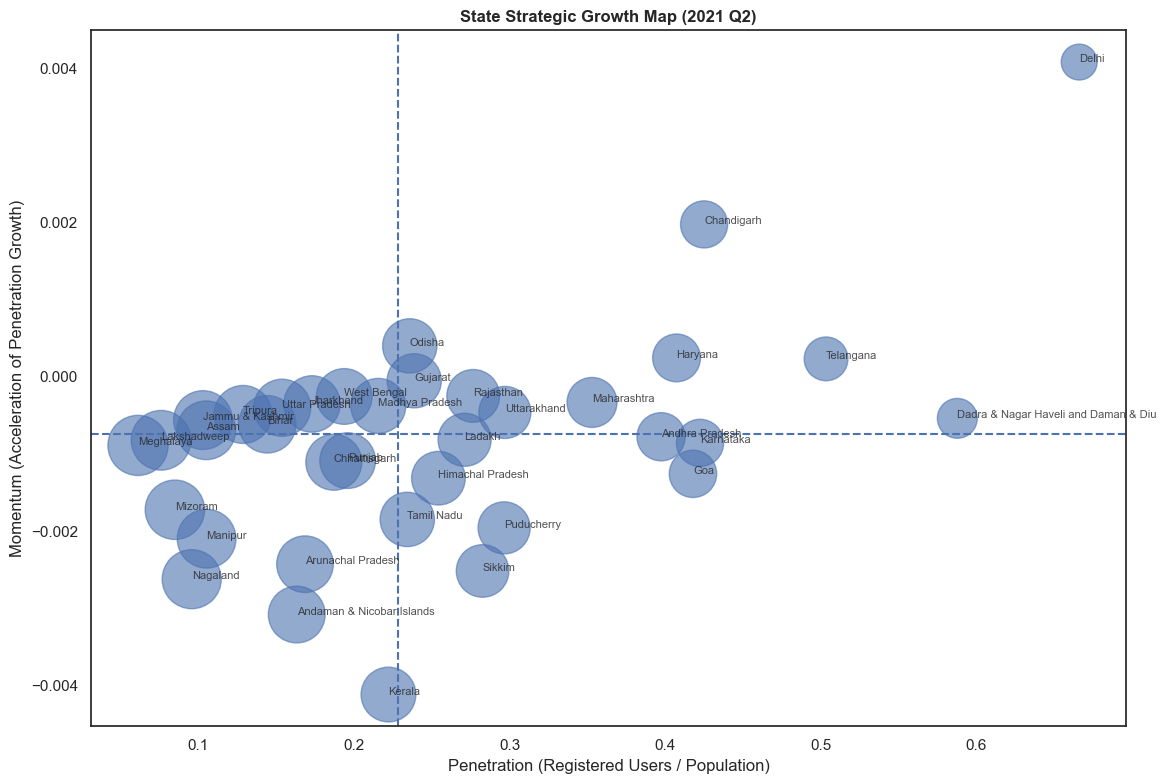

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(12, 8))

# Scatter
plt.scatter(
    latest["Penetration"],
    latest["Momentum"],
    s=latest["Headroom"] * 2000,  # bubble size scaling
    alpha=0.6
)

# Add state labels
for _, row in latest.iterrows():
    plt.text(
        row["Penetration"],
        row["Momentum"],
        row["State"],
        fontsize=8,
        alpha=0.8
    )

# Quadrant lines
plt.axvline(x_mid, linestyle="--")
plt.axhline(y_mid, linestyle="--")

plt.xlabel("Penetration (Registered Users / Population)")
plt.ylabel("Momentum (Acceleration of Penetration Growth)")
plt.title("State Strategic Growth Map (2021 Q2)", weight="bold")

plt.tight_layout()
plt.show()

## <a id="Conc">Semi-Conclusion in Absence of Strategic Input</a>

[⬅ Go Back to Menu](#Menu)

If we don’t have strategic direction, the data is not necessarily suggesting what to __**decide**__ . 

### But

- State-level analysis can be used to deploy capital, search for leadership attention, and alter long-term bets.
- District-level analysis helps us to evaluate distribution of workforce and intensity of operating.
- Locality-level analysis (if it was given) would show where execution is actually succeeding or failing on the ground.

In Short — state suggest where to invest, district suggest how to deploy, locality suggest how to win.

Not layering it like this, we risk bad analysis instead of structured growth.

Strategic Input is necessary to draw directed conculsions, this data can provide impactful analysis.